# Setting up a basic ReAct Agent in LangGraph

In [142]:
import os

os.environ["OPENAI_API_KEY"] = 'sk-***'
os.environ["SERPAPI_API_KEY"] = 's***'  # https://serpapi.com for a free token!

In [2]:
from langchain_community.agent_toolkits.load_tools import load_tools
tools = load_tools(["serpapi"])


In [3]:
tools[0].run('Sinan Ozdemir')

'[\'Ozdemir Sinan : Sinan is an active lecturer focusing on large language models and a former lecturer of data science at the Johns Hopkins University. He is the author of multiple textbooks on data science and machine learning including "Quick Start Guide to LLMs". ...\', \'Sinan Ozdemir type: Author.\', \'Sinan Ozdemir entity_type: people.\', \'Sinan Ozdemir kgmid: /g/11hcjs9cr6.\', "I\'ve spent 12+ years at the intersection of AI research, education, and building: from founding Kylie.ai (YC, acquired) and patenting tool-use agents in 2018, ...", \'Helping companies leverage AI technology to solve complex problems. Founder, author, and consultant specializing in AI, LLMs, and data science.\', \'Data Scientist + Author + Entrepreneur. Check out my new book on LLMs on Amazon (Top 10 in AI/NLP) - sinanuozdemir.\', "A beginner\'s guide to essential math and coding skills for data fluency and machine learning by Sinan Ozdemir", \'Sinan is a former lecturer of Data Science at Johns Hopkin

# Use [Ollama](https://ollama.com/) for local inference

In [5]:
!python -m pip install -qU langchain-ollama


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [1]:
!ollama pull llama3.1

]11;?\pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest ⠧ pulling manifest ⠇ pulling manifest ⠏ pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest 
pulling 667b0c1932bc:   0% ▕                  ▏ 2.3 MB/4.9 GB                  pulling manifest 
pulling 667b0c1932bc:   0% ▕                  ▏ 3.5 MB/4.9 GB                  pulling manifest 
pulling 667b0c1932bc:   0% ▕                  ▏ 5.5 MB/4.9 GB                  pulling manifest 
pulling 667b0c1932bc:   0% ▕                  ▏ 7.2 MB/4.9 GB                  pulling manifest 
pulling 667b0c1932bc:   0% ▕                  ▏ 8.7 MB/4.9 GB                  pulling manifest 
pulling 667b0c1932bc:   0% ▕                  ▏  11 MB/4.9 GB                  pulling manifest 
pulling 667b0c1932bc:   0% ▕                  ▏  13 MB/4.9 GB                  pulling manifest 
pulling 66

In [6]:
from langchain.agents import create_agent
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="llama3.1",
    temperature=1
)
agent_executor = create_agent(llm, tools, system_prompt='Today is Jun 26th, 2026')  # true as of today :)

In [15]:
response = agent_executor.invoke({"messages": [("user", "Who is the current Ravens QB?")]})

In [16]:
response['messages'][-1].content

'The current Ravens QB is Lamar Jackson and also backup QB is Tyler Huntley.'

In [9]:
# if I didn't put the date in, it would use a past year like 2023 as the query instead of
#  {"query":"current Baltimore Ravens quarterback 2025"}
for event in agent_executor.stream({"messages": [("user", "Who is the current Ravens QB?")]}):
    print(event)


{'model': {'messages': [AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.1', 'created_at': '2026-06-26T15:16:57.239773Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1506882583, 'load_duration': 129925000, 'prompt_eval_count': 182, 'prompt_eval_duration': 597875250, 'eval_count': 20, 'eval_duration': 768861961, 'logprobs': None, 'model_name': 'llama3.1', 'model_provider': 'ollama'}, id='lc_run--019f0481-6133-7312-83f5-71d4d611e9ee-0', tool_calls=[{'name': 'Search', 'args': {'__arg1': 'Current Ravens QB'}, 'id': 'ae3cfe74-dab2-4903-b8d9-da2f56bba908', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 182, 'output_tokens': 20, 'total_tokens': 202})]}}
{'tools': {'messages': [ToolMessage(content='[\'The Baltimore Ravens are a professional American football team based in Baltimore. The Ravens compete in the National Football League as a member of the American Football Conference North division. The team plays its home ga

In [13]:
print(event['model']['messages'][-1].content)

The current Ravens QB is Lamar Jackson.


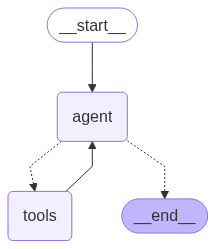

In [14]:
# Compile the graph
from IPython.display import Image, display

display(Image(agent_executor.get_graph().draw_mermaid_png()))

In [15]:
response = agent_executor.invoke({"messages": [("user", "Who is Sinan Ozdemir?")]})

print(response['messages'][-1].content)

Sinan Ozdemir is a data scientist, start-up founder, and educator living in the San Francisco Bay Area. He studied pure mathematics at the Johns Hopkins University.


# Turn our ReAct Agent into a Chat

In [16]:
from langgraph.graph import MessagesState, END, StateGraph, START
from langchain_core.messages import HumanMessage, AIMessage

In [17]:
class ConvoState(MessagesState):
    # MessagesState already has messages in it
    end: bool

def get_user_input(state):
    user_msg = input("\n🧑 You: ")
    if user_msg.strip().lower() == "exit":
        return {'end': True}
    return {"messages": HumanMessage(content=user_msg)}

def run_agent(state):
    print(f'num of messages: {len(state["messages"])}')
    response = agent_executor.invoke({"messages": state["messages"]})
    print(f"\n🤖 Agent: {response['messages'][-1].content}")
    print(f'num of messages: {len(response['messages'])}')
    return {"messages": response['messages'][len(state['messages']):]}

graph_builder = StateGraph(ConvoState)
graph_builder.add_node("get_user_input", get_user_input)
graph_builder.add_node("run_agent", run_agent)

graph_builder.set_entry_point("get_user_input")
graph_builder.add_conditional_edges(
    "get_user_input", 
    lambda state: 'end' if state.get('end') else 'go',
    {
        'end': END,
        'go': 'run_agent'
    }
)
graph_builder.add_edge("run_agent", "get_user_input")

graph = graph_builder.compile()

In [52]:

print("💬 Start chatting with the agent! Type 'exit' to stop.")
state = graph.invoke({"messages": []})

💬 Start chatting with the agent! Type 'exit' to stop.



🧑 You:  hi


num of messages: 1

🤖 Agent: You said "hi". How can I assist you today?
num of messages: 4



🧑 You:  weather in sf please


num of messages: 5

🤖 Agent: The current weather in San Francisco is partly cloudy with a temperature of 68°F (20°C), humidity of 67%, wind speed of 10 mph, and no precipitation. The forecast for this date shows the same conditions throughout the day. Would you like more information or the weather for another location?
num of messages: 8



🧑 You:  thanks


num of messages: 9

🤖 Agent: You're welcome. Is there anything else I can assist you with?
num of messages: 12



🧑 You:  exit


In [60]:
# Note the bad first tool call even if the transcript itself to the human seemed ok, that's a wasted tool call
for message in state['messages']:
    print(type(message), message.content, 'Tool ID:' + message.tool_call_id if hasattr(message, 'tool_call_id') else '')
    if message.additional_kwargs.get('tool_calls'):
        tool_calls = message.additional_kwargs.get('tool_calls')
        for tool_call in tool_calls:
            print(f'Tool Call: ID({tool_call["id"]}), Name({tool_call["function"]["name"]}), Args({tool_call["function"]["arguments"]})')
    elif hasattr(message, 'tool_calls'):
        tool_calls = message.tool_calls
        for tool_call in tool_calls:
            print(f'Tool Call: ID({tool_call["id"]}), Name({tool_call["name"]}), Args({tool_call["args"]})')
    print('----')

<class 'langchain_core.messages.human.HumanMessage'> hi 
----
<class 'langchain_core.messages.ai.AIMessage'>  
Tool Call: ID(414bfaeb-f061-467e-a3d5-5f237db3a1b8), Name(Search), Args({'__arg1': 'hi'})
----
<class 'langchain_core.messages.tool.ToolMessage'> {'type': 'dictionary_results', 'syllables': 'hi', 'word_type': 'exclamation'} Tool ID:414bfaeb-f061-467e-a3d5-5f237db3a1b8
----
<class 'langchain_core.messages.ai.AIMessage'> You said "hi". How can I assist you today? 
----
<class 'langchain_core.messages.human.HumanMessage'> weather in sf please 
----
<class 'langchain_core.messages.ai.AIMessage'>  
Tool Call: ID(27abe48b-c6da-4bb2-b4ab-e2a0b021de62), Name(Search), Args({'__arg1': 'weather in sf'})
----
<class 'langchain_core.messages.tool.ToolMessage'> {'type': 'weather_result', 'temperature': '68', 'unit': 'Fahrenheit', 'precipitation': '0%', 'humidity': '67%', 'wind': '10 mph', 'location': 'San Francisco, CA', 'date': 'Friday 2:00 PM', 'weather': 'Partly cloudy'} Tool ID:27abe48b

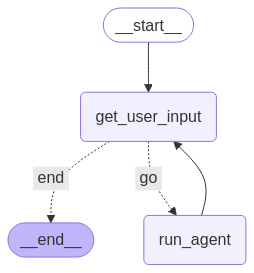

In [86]:
# Compile the graph
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))